# Data Understanding 

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler,PolynomialFeatures
df = pd.read_csv('Salary.csv')
df

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0
...,...,...,...,...,...,...
370,35.0,Female,Bachelor's,Senior Marketing Analyst,8.0,85000.0
371,43.0,Male,Master's,Director of Operations,19.0,170000.0
372,29.0,Female,Bachelor's,Junior Project Manager,2.0,40000.0
373,34.0,Male,Bachelor's,Senior Operations Coordinator,7.0,90000.0


## Section 1

In [3]:
# How many rows and columns are present in the dataset? 

df.shape

(375, 6)

In [4]:
# Which columns have missing values, and how many missing values are there in each? 
df.isnull().sum()

Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64

In [5]:
# . Identify the categorical and numerical columns in the dataset. 

df.dtypes

Age                    float64
Gender                     str
Education Level            str
Job Title                  str
Years of Experience    float64
Salary                 float64
dtype: object

In [6]:
# Calculate the mean, median, and standard deviation of the Age column. 

mean_age = df['Age'].mean()
median_age = df['Age'].median()
std = df['Age'].std()
print(mean_age)
print(median_age)
print(std)

37.43163538873995
36.0
7.069072938567494


In [7]:
# Which gender has a higher proportion in the dataset? Provide percentages. 

gender_counts = df['Gender'].value_counts()
gender_percentages = (df['Gender'].value_counts(normalize=True) * 100).round(2)
higher_gender = gender_counts.idxmax()
higher_percentage = gender_percentages[higher_gender]
print(higher_gender)
print(higher_percentage)

Male
52.01


In [8]:
# List the unique education levels and their proportion in the dataset. 

u = df['Education Level'].unique()
u
p = df['Education Level'].value_counts(normalize=True) * 100
p

Education Level
Bachelor's    60.053619
Master's      26.273458
PhD           13.672922
Name: proportion, dtype: float64

#  Data Cleaning & Preprocessing 

## Section 2

In [9]:
# How many rows contain all NaN values? How would you handle these rows? 

df.isnull().sum()

Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64

In [10]:
df.dropna(inplace=True)
df.isnull().sum()

Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64

In [11]:
# How many duplicate rows are present in the dataset? What effect might keeping 
# duplicates have on model performance? 

df.duplicated().sum()

np.int64(49)

In [12]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

##  Why is it important to reset the index after removing duplicates and NaN rows? 
### When you remove rows (duplicates or NaN values), pandas keeps the original index numbers, creating gaps. This can cause several issues in data analysis.

## Explain why we need to encode categorical variables before building a predictive model? 
### Categorical variables represent discrete groups or categories (e.g., gender, city, education level). However, machine learning algorithms and statistical models are fundamentally mathematical constructs that operate on numerical data. Encoding is the essential bridge that converts categorical information into a format that algorithms can process.

#  Exploratory Data Analysis (EDA)

## Section 3


Skewness coefficient: 0.195


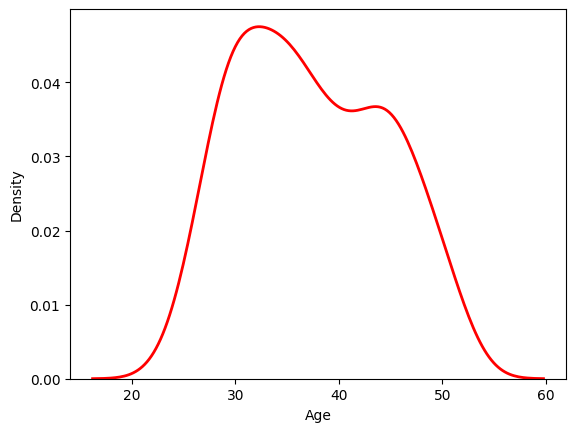

In [13]:
# Plot the distribution of Age. Comment on its skewness.

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
sns.kdeplot(df['Age'], color='red', linewidth=2, label='KDE')
skewness = df['Age'].skew()
skewness_scipy = stats.skew(df['Age'])

print(f"\nSkewness coefficient: {skewness:.3f}")


<Axes: xlabel='Years of Experience'>

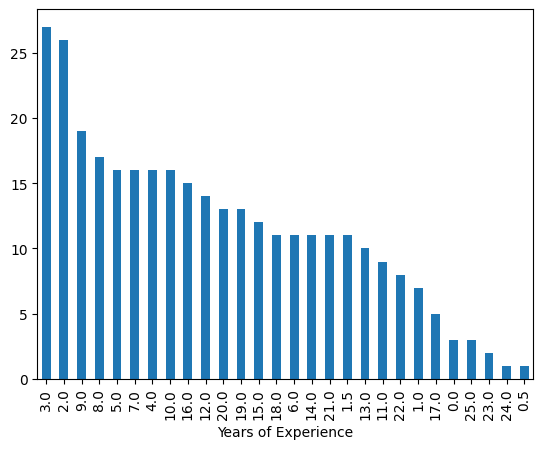

In [14]:
# Plot the distribution of Years of Experience. What can you infer about the 
# experience levels of employees? 
import matplotlib.pyplot as plt
df["Years of Experience"].value_counts().plot(kind="bar")

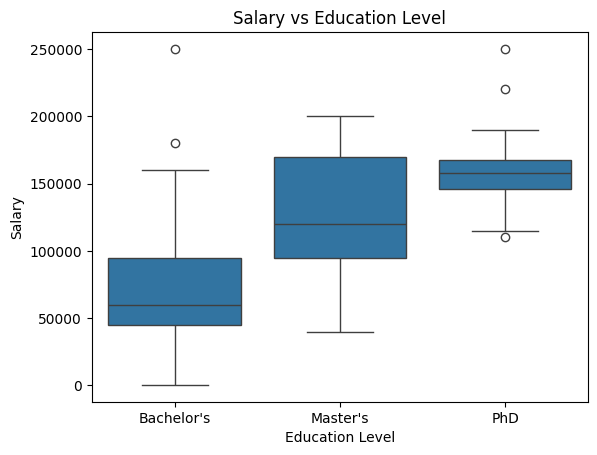

In [15]:
#  Plot a boxplot of Salary vs Education Level. What insights can you derive from this visualization? 

sns.boxplot(x='Education Level', y='Salary', data=df)
plt.title("Salary vs Education Level")
plt.show()


In [16]:
#  Calculate the average salary by gender. Which gender earns more on average? 

df.groupby('Gender')['Salary'].mean()

Gender
Female     96136.363636
Male      103472.647059
Name: Salary, dtype: float64

In [17]:
df.groupby('Education Level')['Salary'].mean()

Education Level
Bachelor's     73902.356021
Master's      127912.087912
PhD           158095.238095
Name: Salary, dtype: float64

In [18]:
df.groupby('Years of Experience')['Salary'].mean()

Years of Experience
0.0      33333.333333
0.5      35000.000000
1.0      37857.142857
1.5      36395.454545
2.0      42115.384615
3.0      51296.296296
4.0      58125.000000
5.0      63750.000000
6.0      82272.727273
7.0      83750.000000
8.0      89117.647059
9.0     101842.105263
10.0     99375.000000
11.0    101111.111111
12.0    103214.285714
13.0    119000.000000
14.0    123181.818182
15.0    129166.666667
16.0    157666.666667
17.0    143000.000000
18.0    146818.181818
19.0    165769.230769
20.0    168846.153846
21.0    172727.272727
22.0    160000.000000
23.0    177500.000000
24.0    250000.000000
25.0    200000.000000
Name: Salary, dtype: float64

In [19]:
df_encoded =pd.get_dummies(df,drop_first=True)

# Correlation & Relationships 

## Section 4

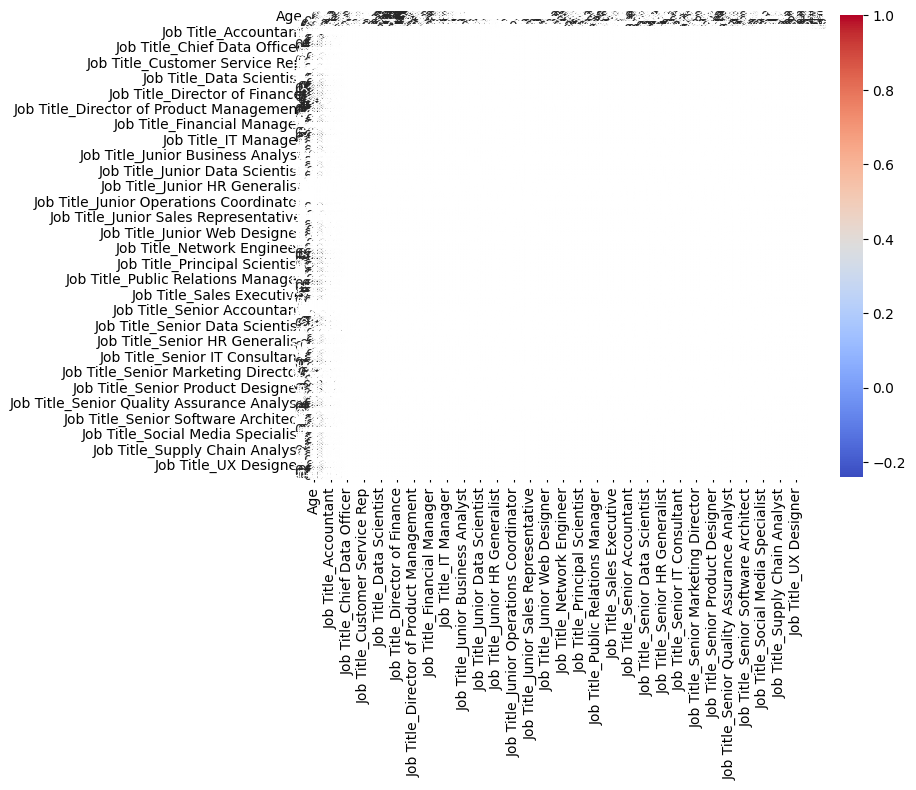

In [20]:
# Create a correlation heatmap of numerical columns. Which features are strongly correlated with Salary? 

plt.figure(figsize=(8,6))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm')
plt.show()

# ...existing code...

In [21]:
df

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0
...,...,...,...,...,...,...
348,28.0,Female,Bachelor's,Junior Operations Manager,1.0,35000.0
349,36.0,Male,Bachelor's,Senior Business Development Manager,8.0,110000.0
350,44.0,Female,PhD,Senior Data Scientist,16.0,160000.0
351,31.0,Male,Bachelor's,Junior Marketing Coordinator,3.0,55000.0


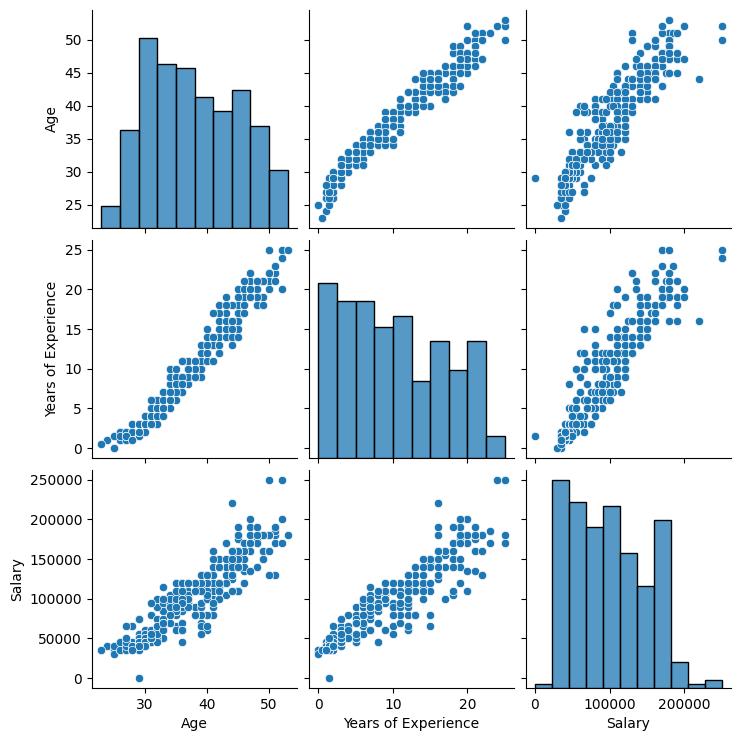

In [25]:
# Create a scatter matrix for numerical variables. Which relationships appear linear? 

sns.pairplot(df)


# Model Building 

## Section 5

In [34]:
# Which columns are selected as features (X) and which as the target (y) for prediction? 
X = df_encoded.drop('Salary', axis=1)
y = df_encoded['Salary']

In [ ]:
# What is the purpose of splitting the dataset into training and testing sets?

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [36]:
#  What algorithm is used for prediction? Why is it suitable for this problem? 

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [37]:
# After fitting the model, what is the training score?

model.score(X_train,y_train)

0.9865584938289437

# Model Prediction & Evaluation 
## Section 6

In [38]:
# Predict the salary for the test dataset and calculate the R² score. What does it indicate about the model? 

y_pred = model.predict(X_test)

from sklearn.metrics import r2_score

r2_score(y_test, y_pred)

0.8670436880629651

In [39]:
#  Calculate the RMSE (Root Mean Squared Error) for predictions. What does this value tell you about prediction accuracy? 

from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
rmse

np.float64(15851.154768860915)

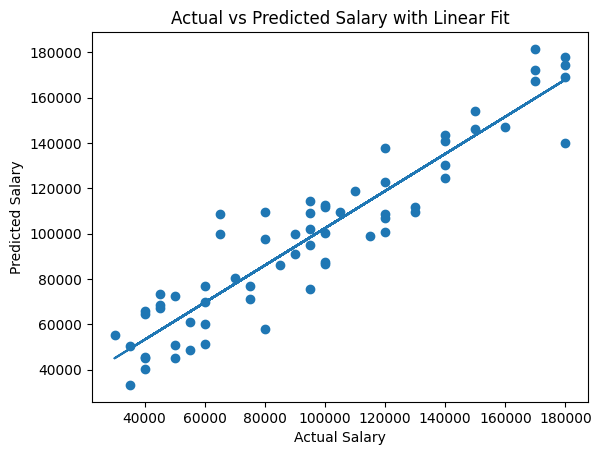

In [40]:
#  Plot predicted vs actual salaries. What insights can you derive from this plot? 

plt.scatter(y_test, y_pred)

m, b = np.polyfit(y_test, y_pred,1 )
plt.plot(y_test, m*y_test + b)

plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary with Linear Fit")

plt.show()

# Section 7: Critical Thinking (Short Answers)
26. Important Features
Years of Experience ✅
Education Level ✅
Age (moderate impact)
27. Important Preprocessing
Removing duplicates
Handling missing values
Encoding categorical variables
28. Improve Model
Feature engineering (e.g., experience²)
Try models:
Random Forest
XGBoost
Hyperparameter tuning
Normalize data